In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
import sys
import os

# Add parent directory to path to import environment
sys.path.append("..") 
from rl_engine.environment import K8sSecurityEnv

# Configuration
MODELS_DIR = "../controller/models_dist"
os.makedirs(MODELS_DIR, exist_ok=True)

In [27]:
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [28]:
def train_and_plot_agent(episodes=500):
    env = K8sSecurityEnv()
    model = DQN(env.observation_space.shape[0], env.action_space.n)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    memory = deque(maxlen=2000)
    epsilon = 1.0
    epsilon_decay = 0.995
    epsilon_min = 0.01
    gamma = 0.99
    batch_size = 32
    
    # Metrics for Plotting
    scores = []
    
    print("Starting RL Training...")
    
    for e in range(episodes):
        state = env.reset()
        total_reward = 0
        
        while True:
            # Action Selection
            if np.random.rand() <= epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    q_values = model(torch.FloatTensor(state))
                    action = torch.argmax(q_values).item()
            
            next_state, reward, done, _ = env.step(action)
            
            memory.append((state, action, reward, next_state, done))
            state = next_state
            total_reward += reward
            
            if done:
                break
            
            # Training Step
            if len(memory) > batch_size:
                batch = random.sample(memory, batch_size)
                # ... (Standard training logic same as script) ...
                for s, a, r, ns, d in batch:
                    target = r
                    if not d:
                        target = r + gamma * torch.max(model(torch.FloatTensor(ns))).item()
                    target_f = model(torch.FloatTensor(s))
                    target_val = target_f.clone().detach()
                    target_val[a] = target
                    optimizer.zero_grad()
                    loss = criterion(target_f, target_val)
                    loss.backward()
                    optimizer.step()

        if epsilon > epsilon_min:
            epsilon *= epsilon_decay
            
        scores.append(total_reward)
        if e % 50 == 0:
            print(f"Episode {e} | Reward: {total_reward:.2f}")

    # Save Model (Sync with Production)
    torch.save(model.state_dict(), f"{MODELS_DIR}/dqn_agent.pth")
    print("Agent Saved.")
    
    return scores

# Run Training
scores = train_and_plot_agent(episodes=500)

Starting RL Training...
Episode 0 | Reward: 17.00
Episode 50 | Reward: 88.00
Episode 100 | Reward: 102.00
Episode 150 | Reward: 185.00
Episode 200 | Reward: 261.00
Episode 250 | Reward: 238.00
Episode 300 | Reward: 219.00
Episode 350 | Reward: 278.00
Episode 400 | Reward: 285.00
Episode 450 | Reward: 362.00
Agent Saved.


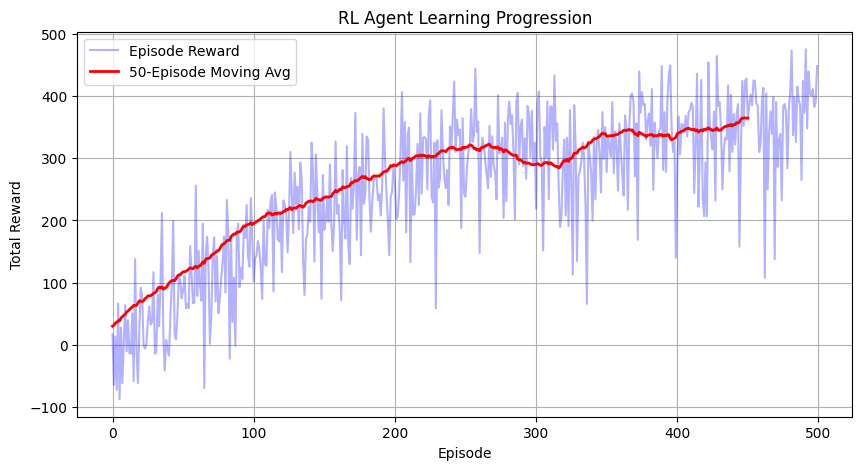

In [29]:
# Plotting the Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(scores, label='Episode Reward', color='blue', alpha=0.3)

# Calculate Moving Average (Trend Line)
moving_avg = np.convolve(scores, np.ones(50)/50, mode='valid')
plt.plot(range(len(moving_avg)), moving_avg, label='50-Episode Moving Avg', color='red', linewidth=2)

plt.title('RL Agent Learning Progression')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()